In [1]:
#Importing Libraries

In [3]:
import pandas as pd

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#Import Dataset

In [6]:
df=pd.read_csv("C:/Code/Loan Prediction - Python/Data/train.csv")

In [7]:
#View Data

In [8]:
print(df.head())
print(df.info())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [9]:
#Data Cleaning

In [10]:
#Fill missing values

In [11]:
df['Gender']=df['Gender'].fillna(df['Gender'].mode()[0])
df['Married']=df['Married'].fillna(df['Married'].mode()[0])
df['Dependents']=df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed']=df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['LoanAmount']=df['LoanAmount'].fillna(df['LoanAmount'].mean())
df['Loan_Amount_Term']=df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History']=df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [12]:
#Exploratory Data Analysis

In [13]:
#Loan Status Count

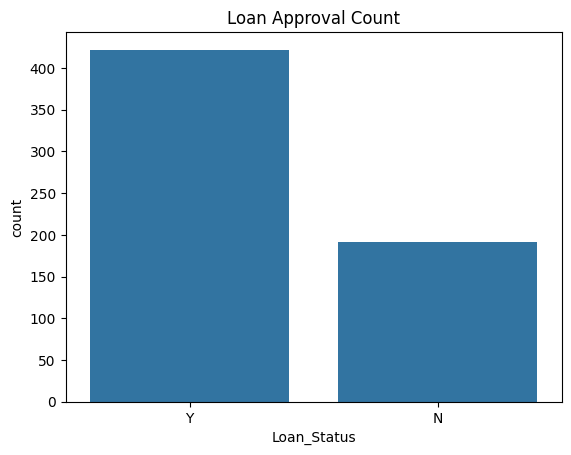

In [14]:
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Approval Count")
plt.show()

In [15]:
#Income vs Loan Status

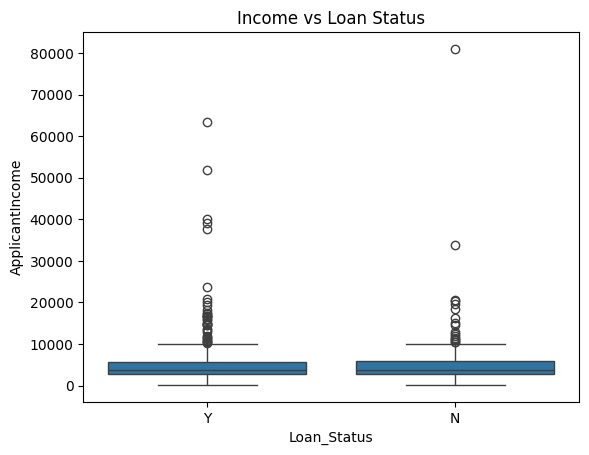

In [16]:
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df)
plt.title("Income vs Loan Status")
plt.show()

In [17]:
#Credit History vs Loan Status

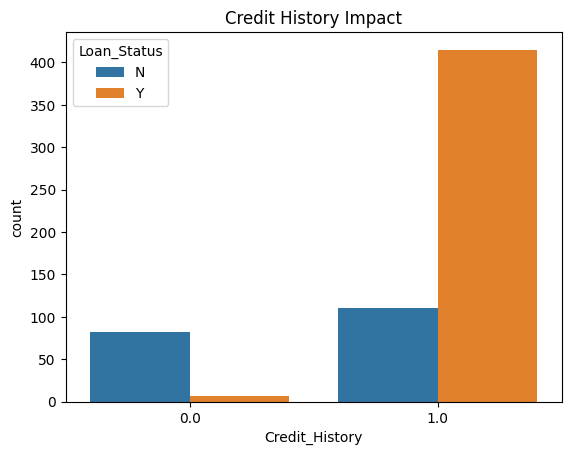

In [18]:
sns.countplot(x='Credit_History',hue='Loan_Status',data=df)
plt.title("Credit History Impact")
plt.show()

In [40]:
#Loan Amount vs Loan Status

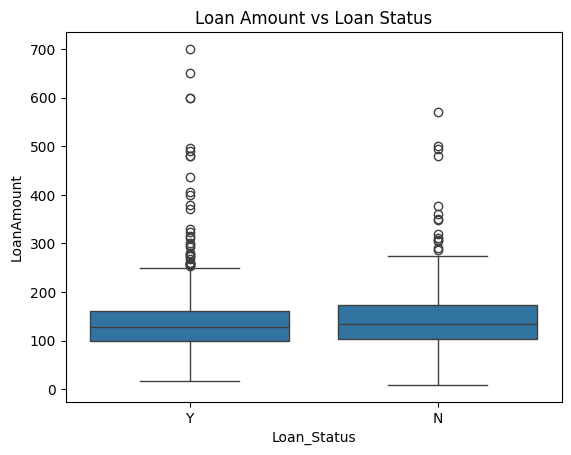

In [42]:
sns.boxplot(x='Loan_Status',y='LoanAmount', data=df)
plt.title("Loan Amount vs Loan Status")
plt.show()

In [ ]:
#Property Area Trend

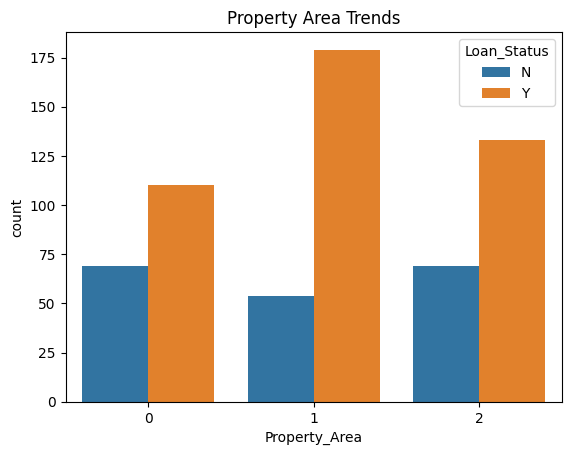

In [43]:
sns.countplot(x='Property_Area',hue='Loan_Status',data=df)
plt.title("Property Area Trends")
plt.show()

In [19]:
#Convert Categorical to Numeric

In [20]:
df = df.replace({'Gender':{'Male':1, 'Female':0},
                 'Married':{'Yes':1,'No':0},
                  'Education':{'Graduate':1,'Not Graduate':0},
                   'Self_Employed':{'Yes':1,'No':0},
                    'Property_Area':{'Urban':2,'Semiurban':1,'Rural':0},
                     'Loan_Status':{'Yes':1,'No':0}})

In [21]:
#Dependent column fix

In [22]:
df['Dependents'] = df['Dependents'].replace('3+',3).astype(int)

In [23]:
#Feature Selection

In [24]:
x=df.drop(columns=['Loan_ID','Loan_Status'])
y=df['Loan_Status']

In [25]:
#Train-Test Split

In [26]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=42) 

In [27]:
#Scaling the Data

In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [29]:
#Model Building (Logistic Regression)

In [30]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

model.fit(x_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [31]:
#Prediction

In [32]:
y_pred=model.predict(x_test_scaled)

In [33]:
#Evaluation

In [34]:
from sklearn.metrics import accuracy_score , confusion_matrix

print("Accuracy:", accuracy_score(y_test,y_pred))
print("Confusion_Matrix:\n", confusion_matrix(y_test,y_pred))

Accuracy: 0.7886178861788617
Confusion_Matrix:
 [[18 25]
 [ 1 79]]


In [35]:
#Feature Importance

In [38]:
importance = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient',ascending=False)

print(importance)

              Feature  Coefficient
9      Credit_History     1.311702
1             Married     0.314327
3           Education     0.160561
2          Dependents     0.118666
10      Property_Area     0.077463
4       Self_Employed     0.050340
8    Loan_Amount_Term     0.046110
5     ApplicantIncome    -0.017872
0              Gender    -0.067265
6   CoapplicantIncome    -0.149490
7          LoanAmount    -0.190539
